# Figure 5 - Transcription-linked Chromatin Deconvolution Results

In [77]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
from pipeline.figure_chromatin_metrics import FigureChromatinMetrics

fig_metrics = FigureChromatinMetrics(output_dir='output/draft4_run/')

In [5]:
fig_metrics.setup_processor()

Starting full expression analysis workflow...
Loaded 9663 transcripts
  5774 genic transcripts
  3889 non-genic transcripts
Loading deconvolved gene expression data...
Loading deconvolved expression files, n= 9663
Loaded expression data: 9663 transcripts, 257 timepoints
Computing PTR values with quantiles 0.1-0.9...
Computed PTR values for 9663 transcripts
PTR range: 1.000 - 8.258
Identified 578 top cycling genes
PTR threshold: 1.168
Top cycling PTR range: 1.168 - 8.258
Loading saved data from output/draft4_run//chromatin_metrics...
  Loading deconvolved data...
    Loaded promoter_occupancy: 9663 genes, 257 timepoints
    Loaded nucleosome_entropy: 9663 genes, 257 timepoints
    Loaded nucleosome_occupancy: 9663 genes, 257 timepoints
    Loaded promoter_occupancy PTRs: 9663 genes
    Loaded nucleosome_entropy PTRs: 9663 genes
    Loaded nucleosome_occupancy PTRs: 9663 genes
  Loading raw_rep1 data...
    Loaded promoter_occupancy: 9663 genes, 16 timepoints
    Loaded nucleosome_entrop

In [6]:
fig_metrics.setup_integration()

promoter_occupancy: n=5774, Pearson r=0.039 (p=2.80e-03), Spearman r=0.037 (p=5.14e-03)
nucleosome_entropy: n=5774, Pearson r=0.093 (p=1.57e-12), Spearman r=0.095 (p=6.12e-13)
nucleosome_occupancy: n=5774, Pearson r=0.080 (p=9.22e-10), Spearman r=0.090 (p=8.37e-12)


/Users/trung/opt/anaconda3/envs/cell-cycle-deconvolution/lib/python3.8/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/Users/trung/opt/anaconda3/envs/cell-cycle-deconvolution/lib/python3.8/site-packages/scipy/stats/_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
/Users/trung/opt/anaconda3/envs/cell-cycle-deconvolution/lib/python3.8/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/Users/trung/opt/anaconda3/envs/cell-cycle-deconvolution/lib/python3.8/site-packages/scipy/stats/_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnin

promoter_occupancy: n=5774, Pearson r=0.010 (p=4.48e-01), Spearman r=0.007 (p=5.71e-01)
nucleosome_entropy: n=5774, Pearson r=0.056 (p=1.80e-05), Spearman r=0.030 (p=2.11e-02)
nucleosome_occupancy: n=5774, Pearson r=0.033 (p=1.19e-02), Spearman r=0.104 (p=1.81e-15)
promoter_occupancy: n=5774, Pearson r=0.009 (p=5.05e-01), Spearman r=-0.002 (p=8.88e-01)
nucleosome_entropy: n=5774, Pearson r=0.051 (p=1.10e-04), Spearman r=0.020 (p=1.21e-01)
nucleosome_occupancy: n=5774, Pearson r=0.021 (p=1.05e-01), Spearman r=0.098 (p=6.84e-14)


In [7]:
from pipeline.chromatin_metrics_4d_analysis import ChromatinMetrics4D

metrics_4d = ChromatinMetrics4D(fig_metrics)
metrics_4d.initialize_tf_processor()

5 genes with nan values were removed
Creating directory: output/draft4_run//chromatin_metrics/clustering...Directory exists. Skipping.
Creating directory: output/draft4_run//figures_transcription_factors...Directory exists. Skipping.
Loading gene promoter data...
Loaded 5774 gene promoters
Loading TF binding datasets...
Number of total factors profiled by Rossi:  319
Number of TFs selected by GO terms (GO:0016563,GO:0043565):  166
Number of TFs with Rossi binding sites:  76
   of these, Kelliher cell-cycle TFS:  12
Found 2793 high-confidence binding sites for 76 cell cycle TFs
Loaded basic results from: output/draft4_run//figures_transcription_factors/binding_results.csv
Loaded comprehensive results from: output/draft4_run//figures_transcription_factors/full_results.csv
Using saved comprehensive results. Use force_recompute=True to regenerate.
Finding TF-gene associations...
Found gene associations for 713/2793 TF binding sites
Integrating gene association data...


Saved figure to: output/draft4_run//chromatin_metrics/clustering/diameters_hist.png
Saved figure to: output/draft4_run//chromatin_metrics/clustering/ptrs_diameter_cutoff.png


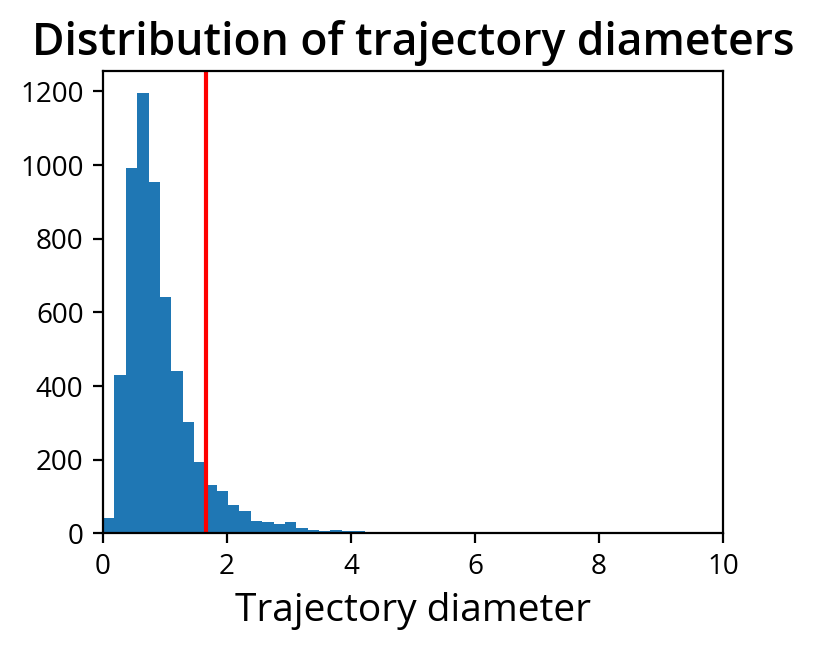

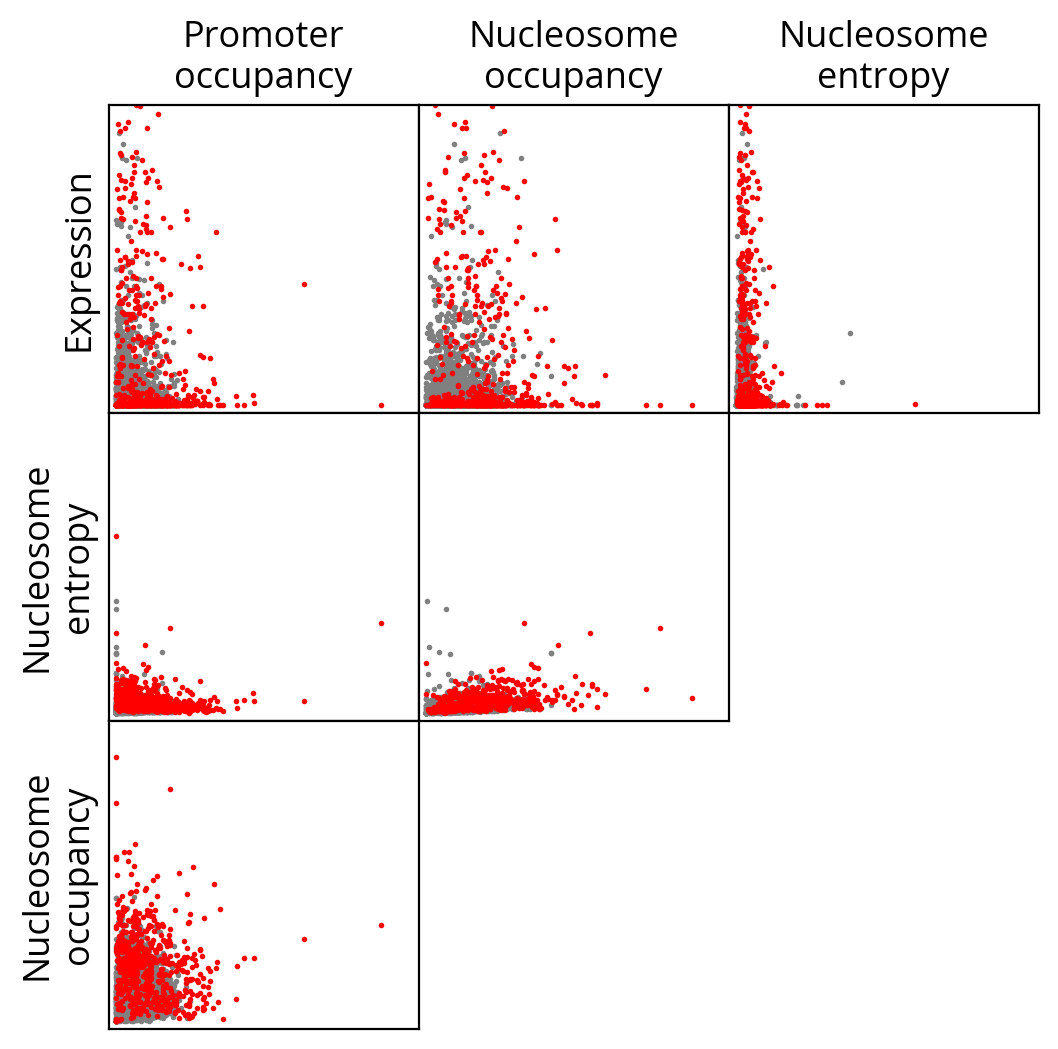

<Figure size 900x600 with 0 Axes>

In [8]:
metrics_4d.threshold_metrics_by_diameter()

The optimal_ke optimal k for clustering is:  20
Saved figure to: k_elbow.png


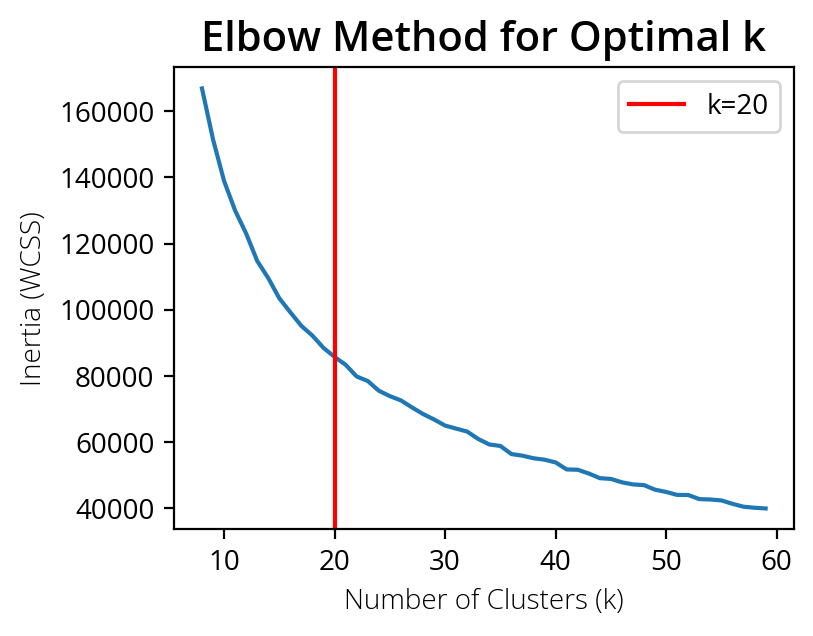

In [9]:
metrics_4d.kmeans_determine_k()

In [10]:
_ = metrics_4d.kmeans_cluster()

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Saved figure to: clusters_PaCMAP.png


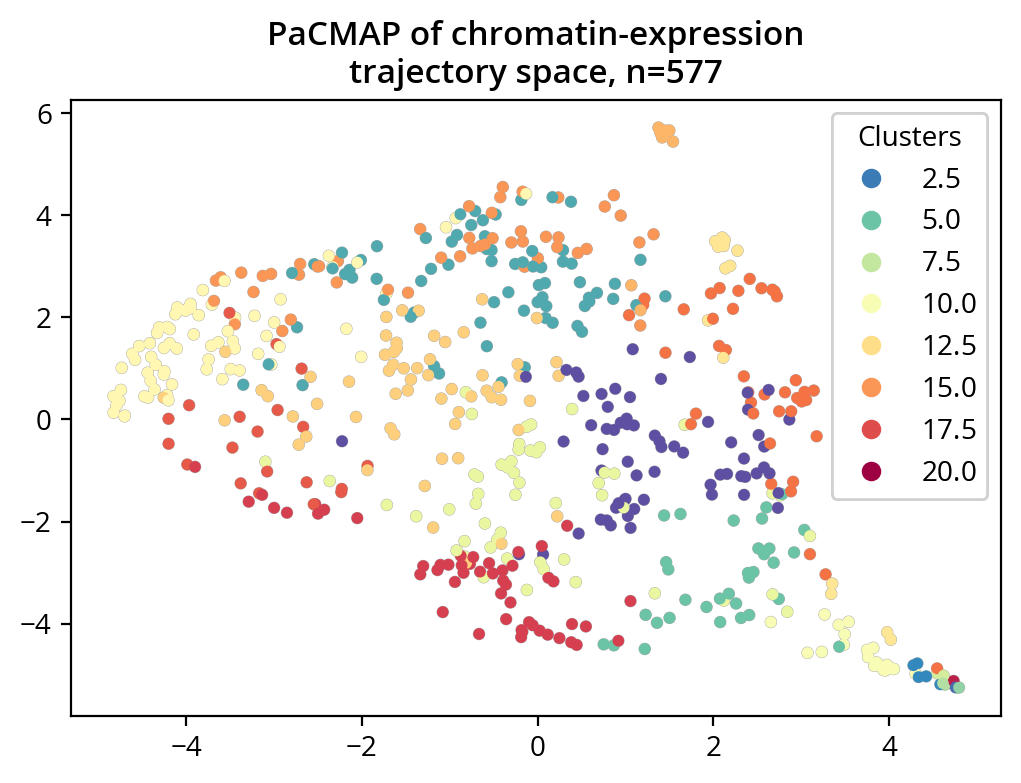

In [11]:
# Plot the filtered data in PaCMAP
metrics_4d.plot_trajectories_PaCMAP()

In [12]:
metrics_4d.run_go_clusters()

./data/goslim_yeast.obo: fmt(1.2) rel(go/2024-09-08/subsets/goslim_yeast.owl) 296 Terms


In [13]:
metrics_4d.sig_results[['id', 'name', 'fdr_bh', 'study_items']]

,id,name,fdr_bh,study_items
cluster,,,,
11,GO:0003677,DNA binding,0.000015,"HTA2,HTA1,HTB2,YOX1,HHT1,HTB1,YHP1,SWI4,HHF1"
11,GO:0006325,chromatin organization,0.001850,"HTA2,HTA1,HTB2,HHT1,HTB1,HHF1"
13,GO:0006260,DNA replication,0.000053,"RFA1,MRC1,TOF1,RFA2,POL1"
13,GO:0006281,DNA repair,0.003103,"RFA1,RAD53,SMC6,MRC1,TOF1,RFA2"


In [14]:
metrics_4d.sig_results[['id', 'name', 'fdr_bh', 'study_items']]#.loc[9].study_items.values

,id,name,fdr_bh,study_items
cluster,,,,
11,GO:0003677,DNA binding,0.000015,"HTA2,HTA1,HTB2,YOX1,HHT1,HTB1,YHP1,SWI4,HHF1"
11,GO:0006325,chromatin organization,0.001850,"HTA2,HTA1,HTB2,HHT1,HTB1,HHF1"
13,GO:0006260,DNA replication,0.000053,"RFA1,MRC1,TOF1,RFA2,POL1"
13,GO:0006281,DNA repair,0.003103,"RFA1,RAD53,SMC6,MRC1,TOF1,RFA2"


In [15]:
metrics_4d.perform_tf_analysis_of_clusters()

[0, 64, 97, 128] 384
Saved figure to: output/draft4_run//chromatin_metrics/clustering/clusters_heatmap.png


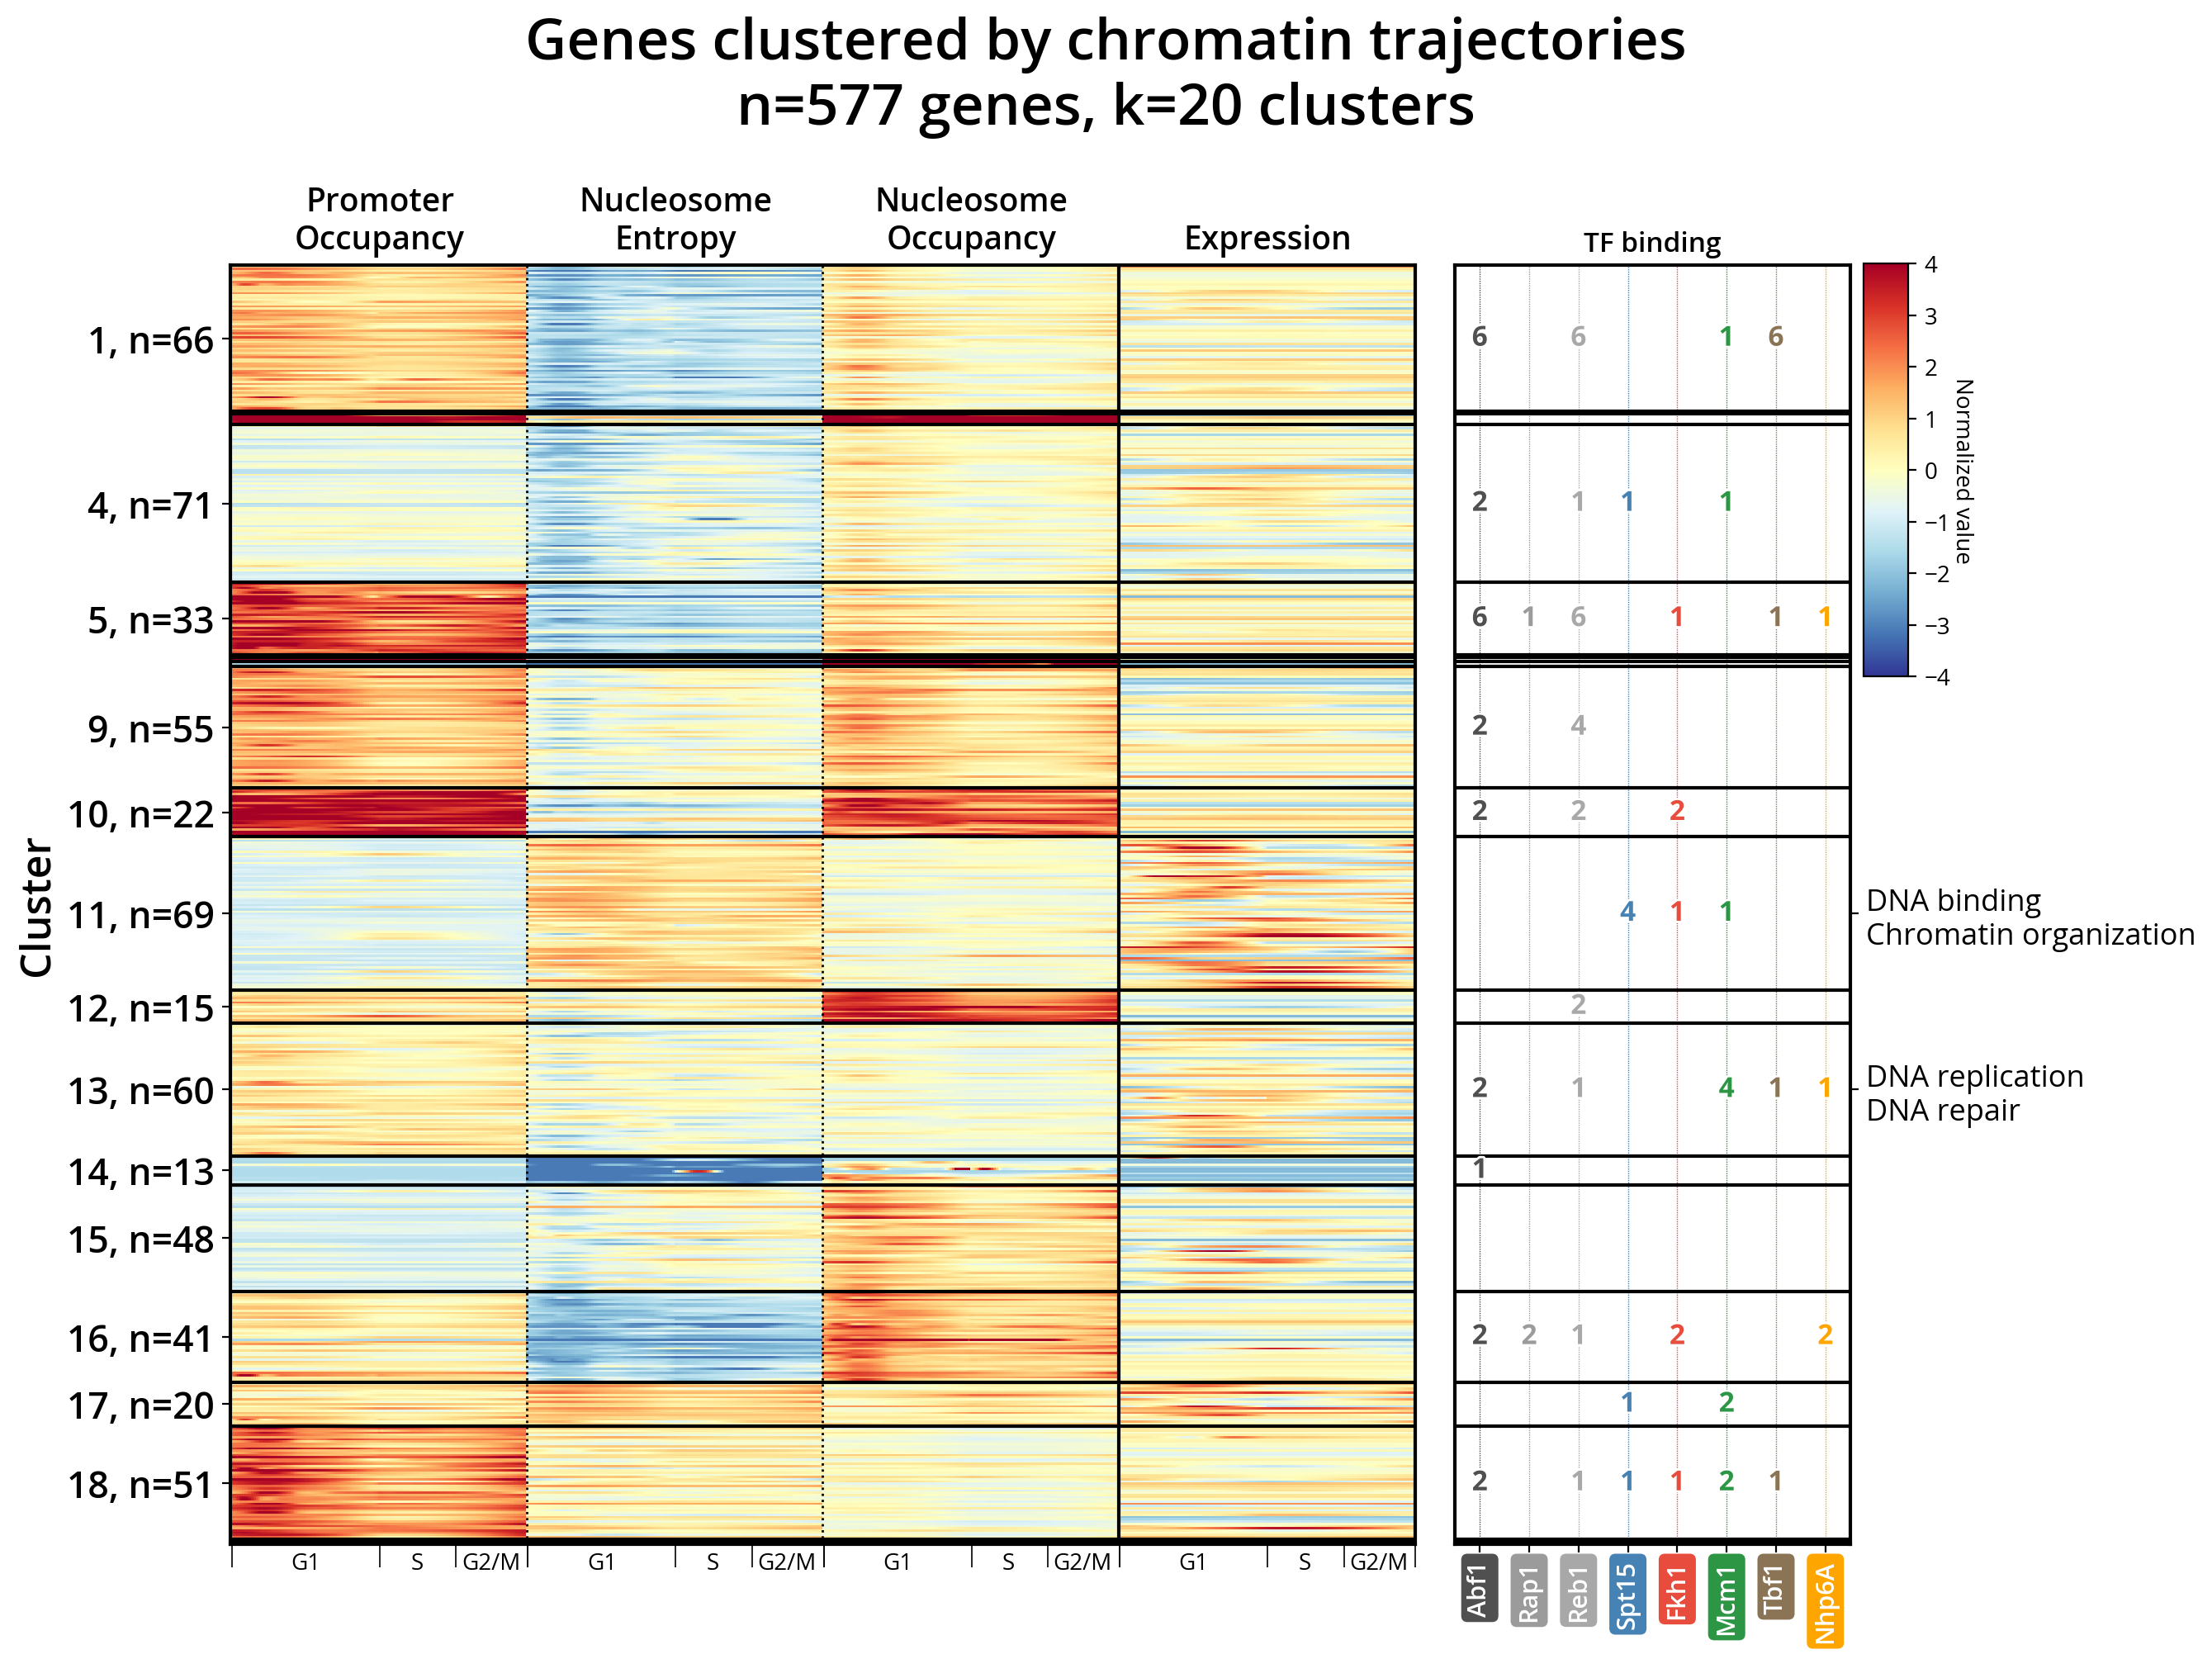

In [57]:
metrics_4d.plot_heatmap_of_clusters()

Creating directory: output/draft4_run//chromatin_metrics/clustering/trajectories...Directory exists. Skipping.
Cluster 13


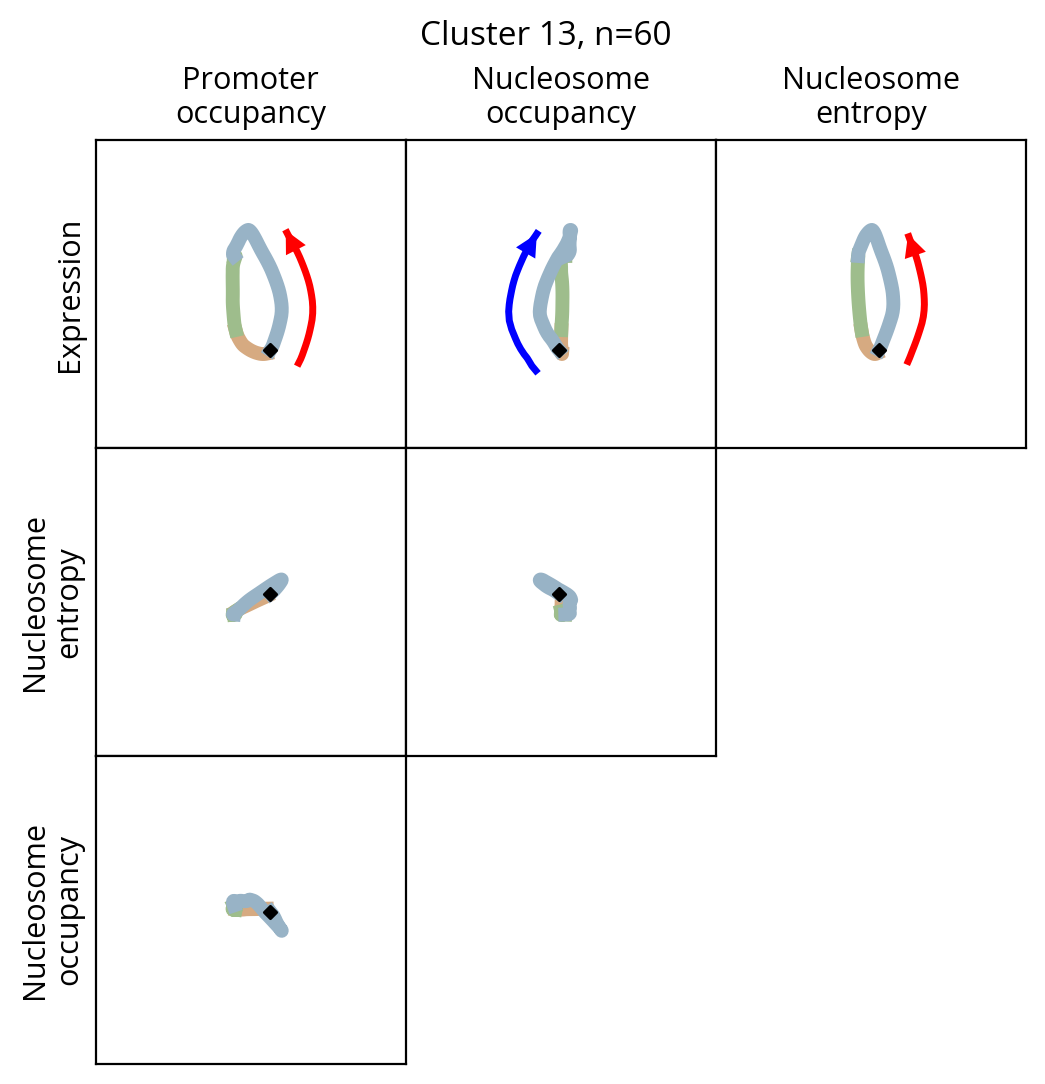

In [94]:
metrics_4d.plot_cluster_trajectories()

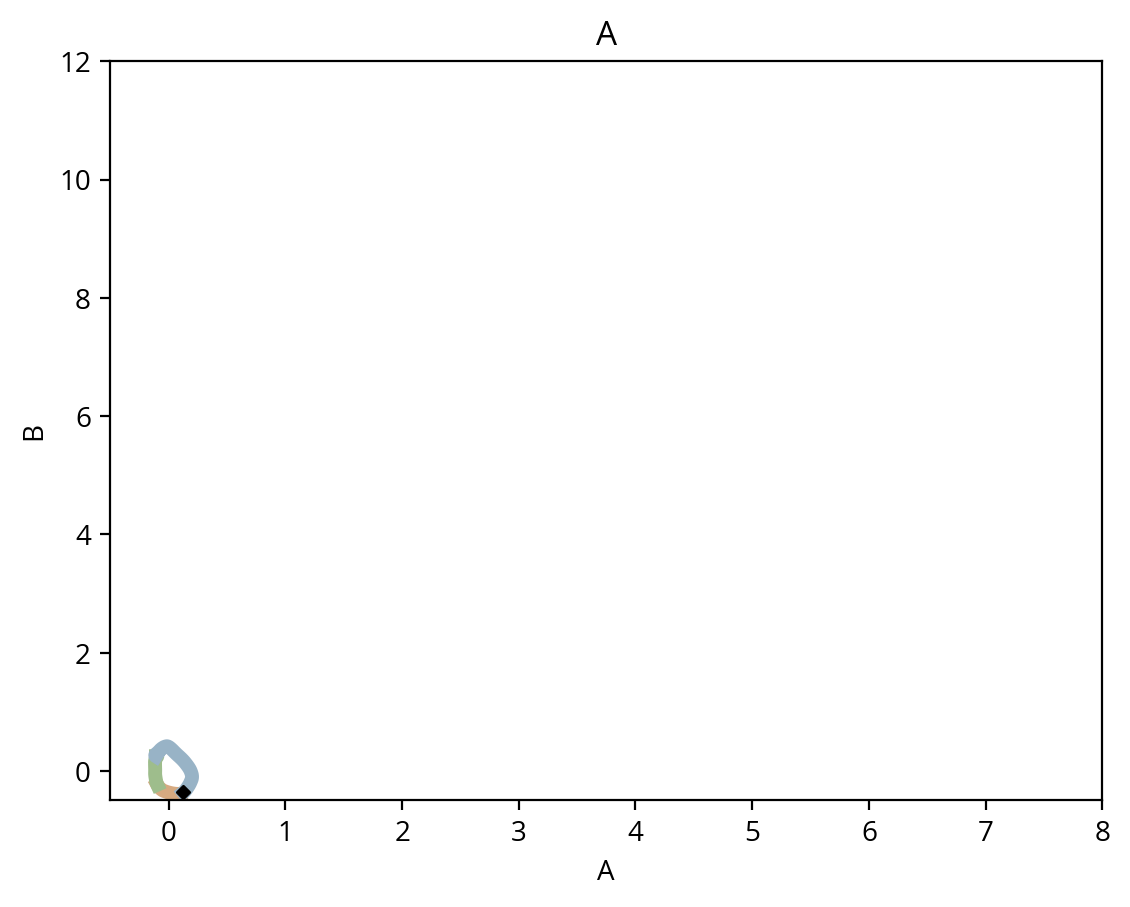

In [78]:
from src.plot_helpers import plot_trajectory_deconvolved_values
from src.config import load_default_chrom_configs

config, _ = load_default_chrom_configs()

ax = plt.gca()
plot_trajectory_deconvolved_values(config, x,
    y, x_key='A',
    y_key='B', ax=ax)


In [31]:
metrics_4d.plot_cluster_mean_3d_plot()

Cluster 1
Saved figure to: output/draft4_run//chromatin_metrics/clustering/trajectories/3d_meta_cluster_1.png
Cluster 2
Saved figure to: output/draft4_run//chromatin_metrics/clustering/trajectories/3d_meta_cluster_2.png
Cluster 3
Saved figure to: output/draft4_run//chromatin_metrics/clustering/trajectories/3d_meta_cluster_3.png
Cluster 4
Saved figure to: output/draft4_run//chromatin_metrics/clustering/trajectories/3d_meta_cluster_4.png
Cluster 5
Saved figure to: output/draft4_run//chromatin_metrics/clustering/trajectories/3d_meta_cluster_5.png
Cluster 6
Saved figure to: output/draft4_run//chromatin_metrics/clustering/trajectories/3d_meta_cluster_6.png
Cluster 7
Saved figure to: output/draft4_run//chromatin_metrics/clustering/trajectories/3d_meta_cluster_7.png
Cluster 8
Saved figure to: output/draft4_run//chromatin_metrics/clustering/trajectories/3d_meta_cluster_8.png
Cluster 9
Saved figure to: output/draft4_run//chromatin_metrics/clustering/trajectories/3d_meta_cluster_9.png
Cluster 10

<Figure size 700x600 with 0 Axes>

<Figure size 700x600 with 0 Axes>

<Figure size 700x600 with 0 Axes>

<Figure size 700x600 with 0 Axes>

...

<Figure size 700x600 with 0 Axes>

<Figure size 700x600 with 0 Axes>

<Figure size 700x600 with 0 Axes>

<Figure size 700x600 with 0 Axes>

<Figure size 700x600 with 0 Axes>

In [53]:
metrics_4d.layout_chromatin_transcription_figure()

Debug figure saved to: output/draft4_run/Figures/Debug/Figure5_Chromatin_Transcription_debug.png
Clean figure saved to: output/draft4_run/Figures/Figure5_Chromatin_Transcription.png
Panel layout saved to: output/draft4_run/Figures/Figure5_Chromatin_Transcription.png


'output/draft4_run/Figures/Figure5_Chromatin_Transcription.png'

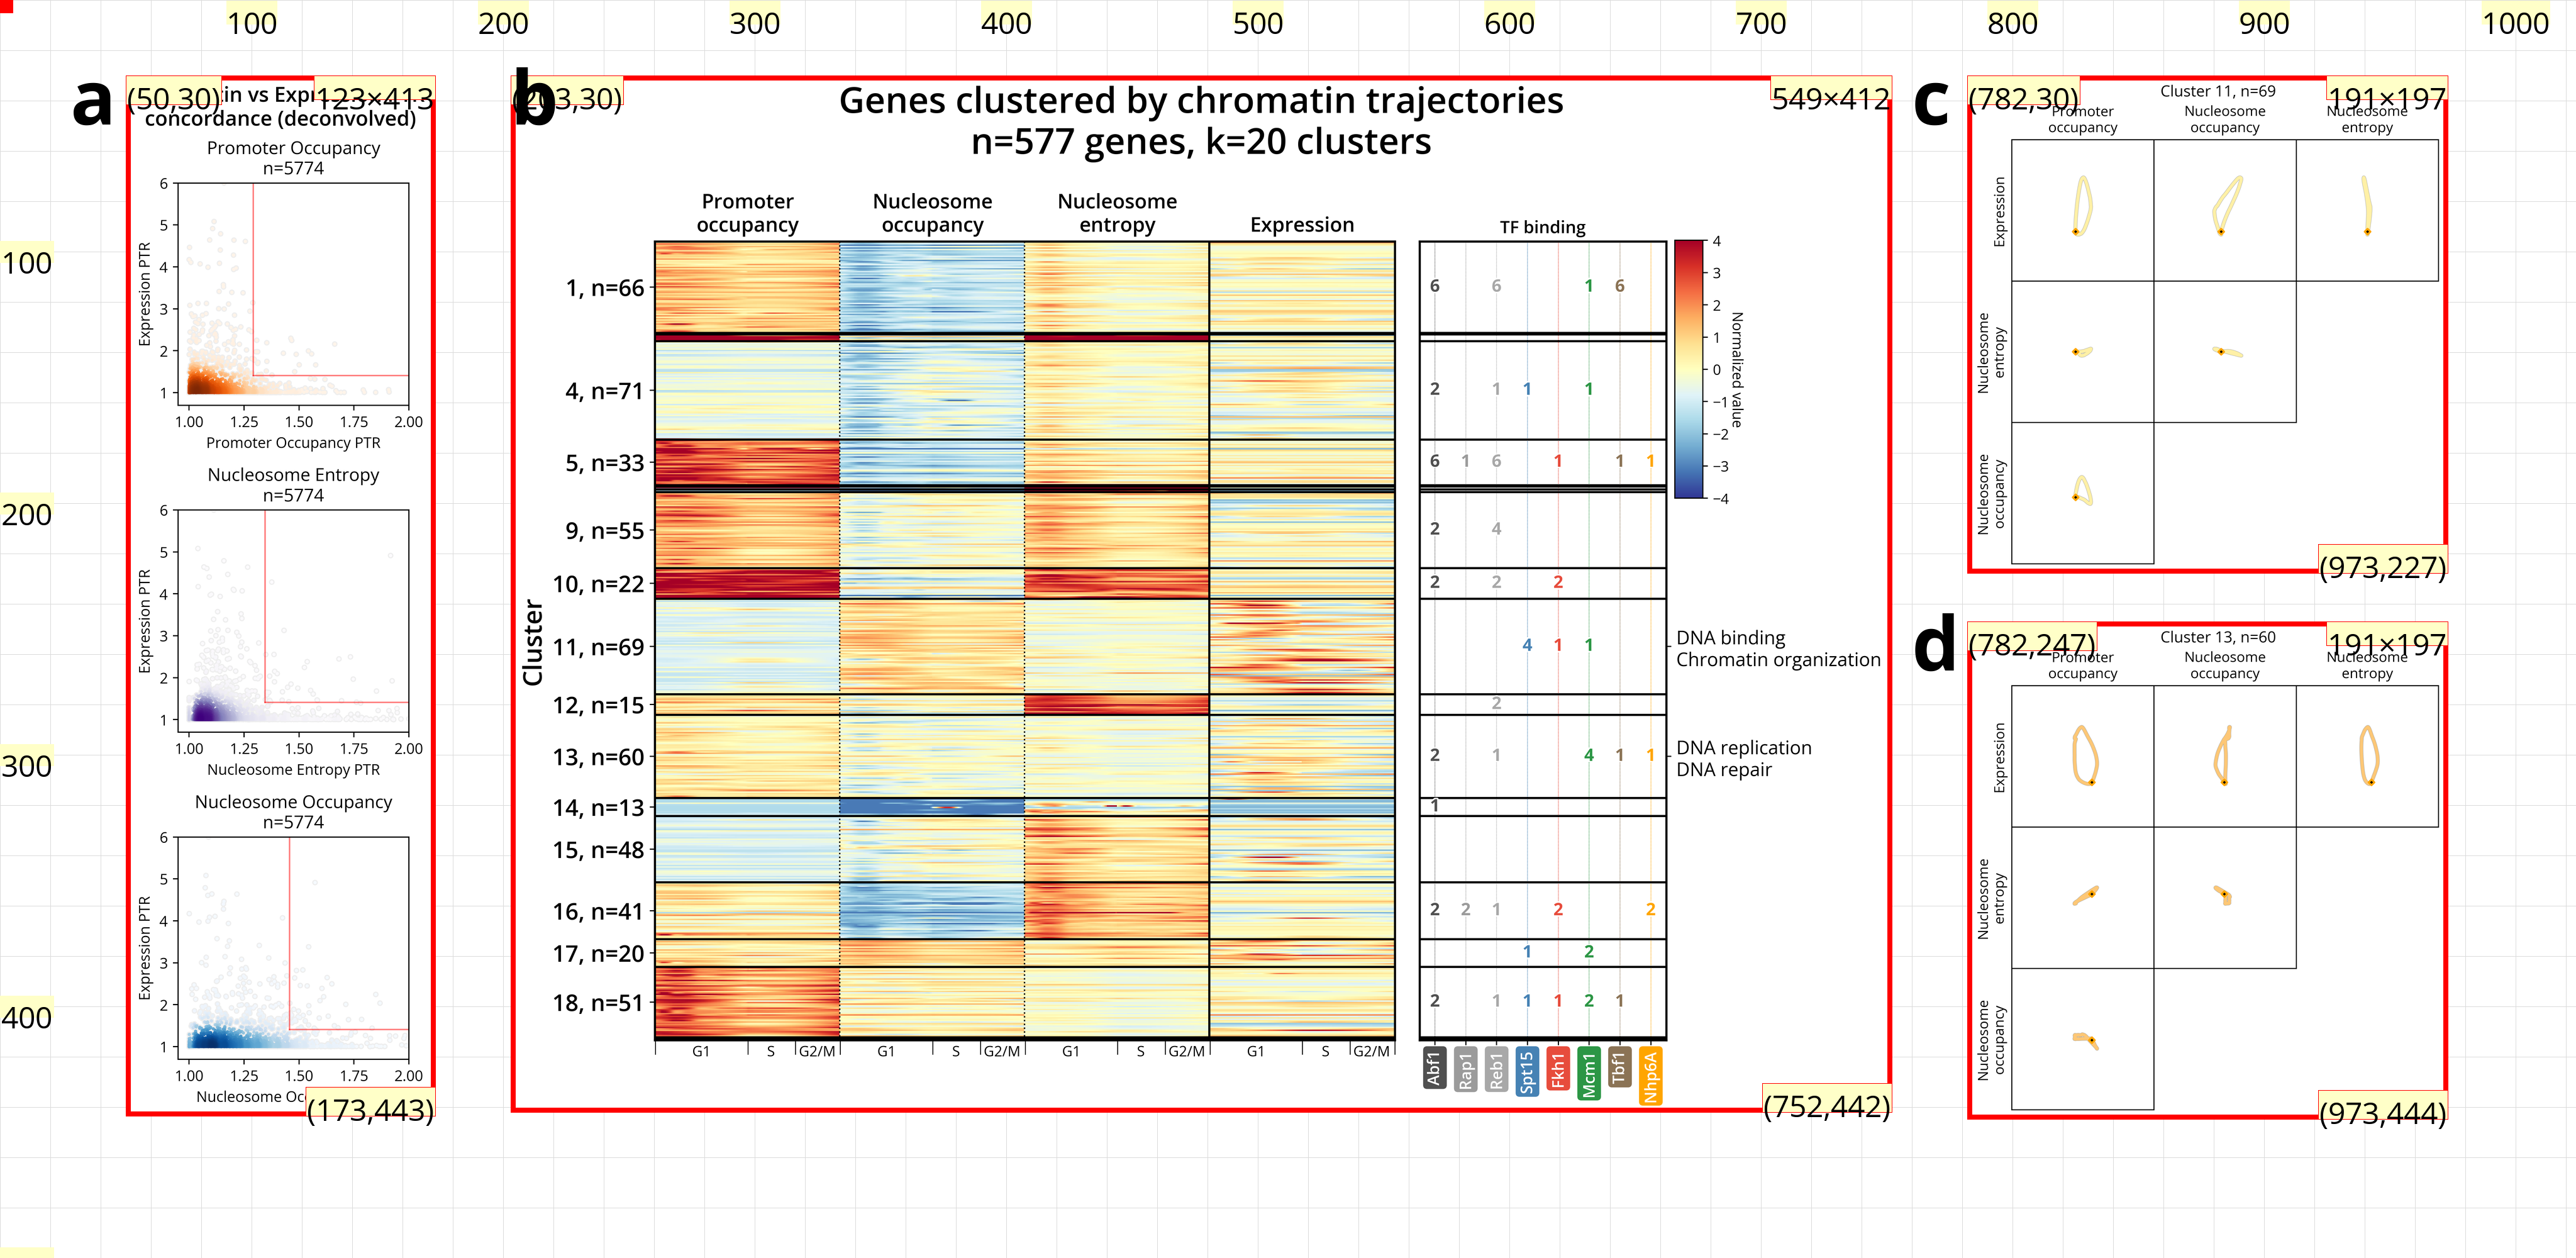

In [54]:
from IPython.display import Image, display
display(Image(f'output/draft4_run/Figures/Debug/Figure5_Chromatin_Transcription_debug.png'))